# Анализ результатов A/B-тестов

Продолжаем тему с A/B-тестами.

На этот раз ситуация следующая: вы работаете в приложении по доставке готовых продуктов.

К вам пришёл коллега с результатами двух тестов:

1. В первом тестировали разрешение фотографий блюд в приложении:
   пользователям показывались либо прямоугольные, либо новые квадратные изображения.

2. Во втором тесте была обновлена кнопка заказа:
   часть пользователей видела старый вариант, часть — новый.

Коллега предварительно посмотрел на графики и предположил, что между группами могут быть различия.

Ваша задача — проверить гипотезы, сделать статистические выводы и принять решение по результатам экспериментов.

---

# Задания

## Тест 1 — изображения блюд

1. Выберите метод, который предположительно подойдёт для анализа первого вопроса.

2. Проверьте, являются ли дисперсии внутри групп гомогенными.

3. Проведите тест на нормальность распределения.

4. Сравните средние значения в представленных группах.

5. Используйте критерий Тьюки и определите, между какими группами имеются статистически значимые различия.

6. Примите решение: какие изображения в итоге будем использовать.

---

## Тест 2 — обновление кнопки заказа

7. Выберите метод для анализа второго теста.

8. Визуализируйте распределение `events` для контрольной и тестовой групп.

9. Посмотрите описательные статистики `events`:
   - в разбивке по группе;
   - в разбивке по пользовательскому сегменту.

10. Выберите формулу для модели.

11. Проведите статистический тест.

---

# Описание данных

## `5_task_1`

| Поле | Описание |
|---|---|
| `id` | идентификатор клиента в эксперименте |
| `group` | вариант изображения |
| `events` | количество заказанных блюд за период |

### Значения `group`

| Группа | Описание |
|---|---|
| `A` | прямоугольные изображения `16:9` |
| `B` | квадратные изображения |
| `C` | прямоугольные изображения `12:4` |

---

## `5_task_2`

| Поле | Описание |
|---|---|
| `id` | идентификатор клиента в эксперименте |
| `segment` | сегмент пользователя (`high` / `low`) |
| `group` | вариант кнопки заказа |
| `events` | количество заказанных блюд за период |

### Значения `group`

| Группа | Описание |
|---|---|
| `control` | старая версия кнопки |
| `test` | новая версия кнопки |

In [13]:
import pandas as pd
import scipy.stats as st

In [5]:
task_1 = pd.read_csv('5_task_1.csv')

In [6]:
task_1.head()

,id,group,events
0,16046,A,14
1,18712,A,41
2,3268,A,30
3,22633,A,37
4,28071,A,38


In [7]:
task_1.shape

(30000, 3)

In [8]:
task_1.isna().sum()

id        0
group     0
events    0
dtype: int64

In [10]:
task_1.dtypes

id         int64
group     object
events     int64
dtype: object

In [11]:
A = task_1.query('group == "A"').events
B = task_1.query('group == "B"').events
C = task_1.query('group == "C"').events

In [14]:
st.levene(A,B,C)

LeveneResult(statistic=np.float64(2.2622596339318037), pvalue=np.float64(0.10413271995240937))

In [15]:
print(st.normaltest(A))
print(st.normaltest(B))
print(st.normaltest(C))


NormaltestResult(statistic=np.float64(2.1034599402238734), pvalue=np.float64(0.3493328906085719))
NormaltestResult(statistic=np.float64(0.8410715800223014), pvalue=np.float64(0.6566948749848232))
NormaltestResult(statistic=np.float64(3.243725809054571), pvalue=np.float64(0.19753037588314623))


In [17]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pingouin]


In [18]:
import pingouin as pg

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

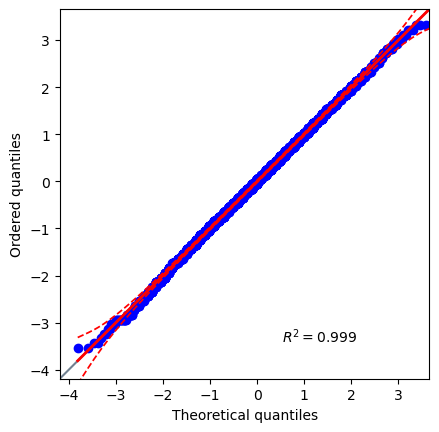

In [19]:
pg.qqplot(A)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

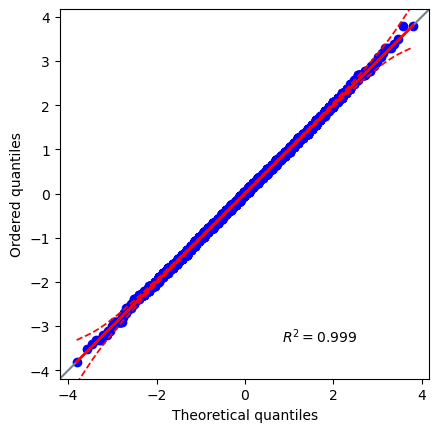

In [20]:
pg.qqplot(B)

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

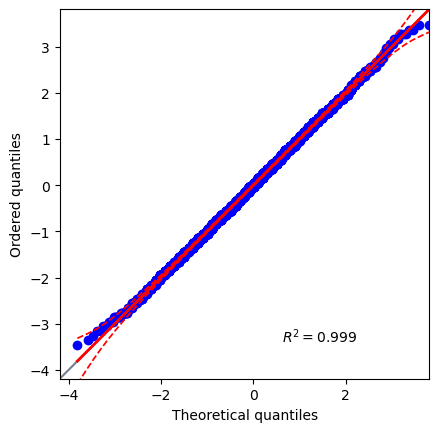

In [22]:
pg.qqplot(C)

In [26]:
st.f_oneway(A,B,C)

F_onewayResult(statistic=np.float64(2886.166657438961), pvalue=np.float64(0.0))

In [27]:
pg.pairwise_tukey(data=task_1, dv="events", between="group")


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,A,B,29.5796,37.6136,-8.0340,0.140894,-57.021604,5.026313e-12,-0.806229
1,A,C,29.5796,27.4703,2.1093,0.140894,14.970833,5.026313e-12,0.210514
2,B,C,37.6136,27.4703,10.1433,0.140894,71.992436,5.026313e-12,1.024138


In [28]:
pg.pairwise_ttests(data=task_1, dv="events", between="group",  padjust="holm")


/opt/anaconda3/lib/python3.13/site-packages/pingouin/pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,group,A,B,False,True,-57.011134,19998.0,two-sided,0.000000e+00,0.000000e+00,holm,inf,-0.806229
1,group,A,C,False,True,14.886135,19998.0,two-sided,7.500262e-50,7.500262e-50,holm,1.054e+46,0.210514
2,group,B,C,False,True,72.420220,19998.0,two-sided,0.000000e+00,0.000000e+00,holm,inf,1.024138


In [29]:
#геймс-хоувелл

pg.pairwise_gameshowell(data=task_1, dv="events", between="group")


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,A,B,29.5796,37.6136,-8.0340,0.140920,-57.011134,19987.258491,2.473022e-12,-0.806229
1,A,C,29.5796,27.4703,2.1093,0.141696,14.886135,19995.116233,6.349254e-12,0.210514
2,B,C,37.6136,27.4703,10.1433,0.140062,72.420220,19995.502469,0.000000e+00,1.024138


Во втором эксперименте требуется проверить, как пользователи отреагируют на изменение формата кнопки оформления заказа, с разбивкой по сегменту клиента.



In [30]:
task_2 = pd.read_csv('5_task_2.csv')

In [31]:
task_2.head()

,id,group,segment,events
0,83440,test,high,78.0
1,96723,test,high,71.0
2,68719,test,high,80.0
3,50399,test,high,80.0
4,95613,test,high,78.0


In [32]:
import seaborn as sns

In [33]:
?sns.histplot

Signature:
sns.histplot(
    data=None,
    *,
    x=None,
    y=None,
    hue=None,
    weights=None,
    stat='count',
    bins='auto',
    binwidth=None,
    binrange=None,
    discrete=None,
    cumulative=False,
    common_bins=True,
    common_norm=True,
    multiple='layer',
    element='bars',
    fill=True,
    shrink=1,
    kde=False,
    kde_kws=None,
    line_kws=None,
    thresh=0,
    pthresh=None,
    pmax=None,
    cbar=False,
    cbar_ax=None,
    cbar_kws=None,
    palette=None,
    hue_order=None,
    hue_norm=None,
    color=None,
    log_scale=None,
    legend=True,
    ax=None,
    **kwargs,
)
Docstring:
Plot univariate or bivariate histograms to show distributions of datasets.

A histogram is a classic visualization tool that represents the distribution
of one or more variables by counting the number of observations that fall within
discrete bins.

This function can normalize the statistic computed within each bin to estimate
frequency, density or probability mas

<Axes: xlabel='events', ylabel='Count'>

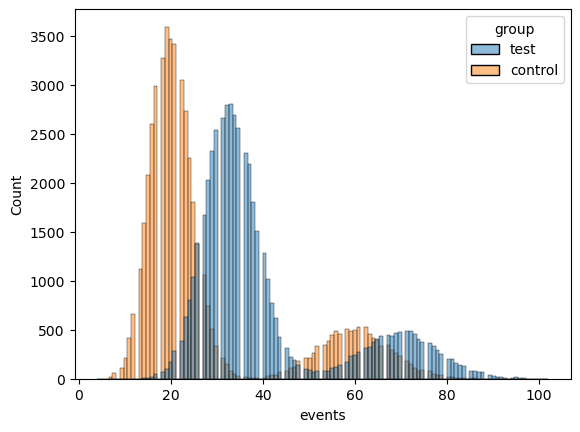

In [34]:
sns.histplot(data = task_2, x = 'events', hue ='group')

In [49]:
task_2.groupby(['group', 'segment']).events.agg( mean_events = 'mean', median_events = 'median', std_events = 'std')

mean_events  median_events  std_events
group   segment                                        
control high       59.970800           60.0    7.805347
        low        20.031575           20.0    4.473576
test    high       69.938500           70.0    8.403974
        low        33.025925           33.0    5.720845

In [50]:
task_2.groupby(['group', 'segment']).events.describe()

count       mean       std   min   25%   50%   75%    max
group   segment                                                             
control high     10000.0  59.970800  7.805347  31.0  55.0  60.0  65.0   89.0
        low      40000.0  20.031575  4.473576   4.0  17.0  20.0  23.0   41.0
test    high     10000.0  69.938500  8.403974  40.0  64.0  70.0  76.0  102.0
        low      40000.0  33.025925  5.720845  13.0  29.0  33.0  37.0   59.0

In [51]:
pg.anova(data=task_2, dv="events", between=['group', 'segment'])


,Source,SS,DF,MS,F,p_unc,np2
0,group,3.837195e+06,1.0,3.837195e+06,112031.864119,0.000000e+00,0.528383
1,segment,2.362480e+07,1.0,2.362480e+07,689756.377485,0.000000e+00,0.873383
2,group * segment,3.664244e+04,1.0,3.664244e+04,1069.823273,2.060261e-233,0.010585
3,Residual,3.424956e+06,99996.0,3.425093e+01,NaN,NaN,NaN


In [54]:
task_2['combination'] = task_2.group + '/'+ task_2.segment
task_2.head()

,id,group,segment,events,combination
0,83440,test,high,78.0,test/high
1,96723,test,high,71.0,test/high
2,68719,test,high,80.0,test/high
3,50399,test,high,80.0,test/high
4,95613,test,high,78.0,test/high


In [56]:
pg.pairwise_tukey(data=task_2, dv="events", between="combination")


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,control/high,control/low,59.970800,20.031575,39.939225,0.065432,610.391461,0.0,7.521612
1,control/high,test/high,59.970800,69.938500,-9.967700,0.082766,-120.432523,0.0,-1.228989
2,control/high,test/low,59.970800,33.025925,26.944875,0.065432,411.798717,0.0,4.350026
3,control/low,test/high,20.031575,69.938500,-49.906925,0.065432,-762.727892,0.0,-9.091140
4,control/low,test/low,20.031575,33.025925,-12.994350,0.041383,-314.002699,0.0,-2.530414
5,test/high,test/low,69.938500,33.025925,36.912575,0.065432,564.135148,0.0,5.814008


<Axes: xlabel='group', ylabel='events'>

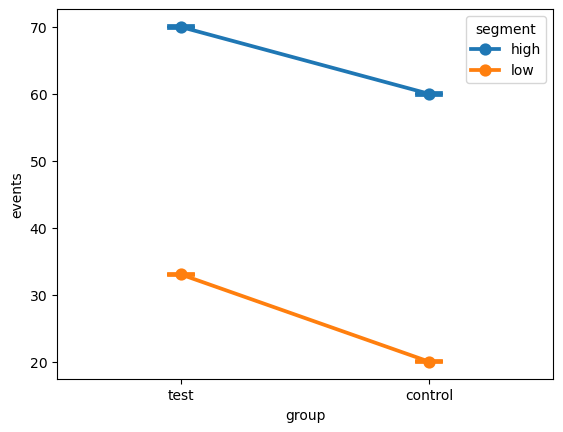

In [59]:
sns.pointplot(x="group",
              y="events", 
              data=task_2, 
              hue='segment',
              capsize=0.1)
